In [12]:
import matplotlib.pyplot as plt
# 设置中文字体支持
import matplotlib.font_manager as fm
# 备选中文字体列表
chinese_fonts = [
    "SimHei",           # Windows
    "Heiti TC",         # macOS
    "WenQuanYi Micro Hei",  # Linux
    "Microsoft YaHei",  # 微软雅黑
    "Arial Unicode MS", # 备选
]

# 获取系统可用字体
available_fonts = {f.name for f in fm.fontManager.ttflist}

# 查找第一个可用的中文字体
for font in chinese_fonts:
    if font in available_fonts:
        plt.rcParams["font.family"] = font
        break

plt.rcParams['axes.unicode_minus'] = False  # 解决负号显示问题

### 240722

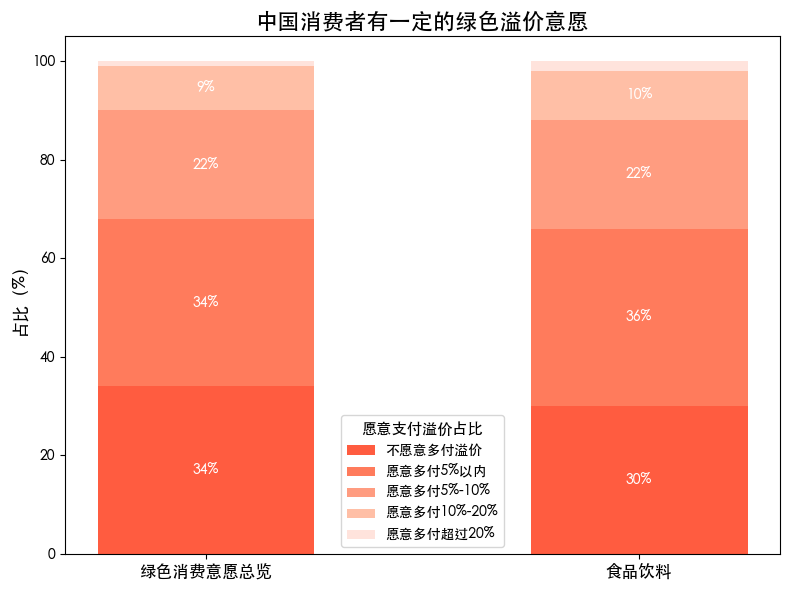

In [13]:
import matplotlib.pyplot as plt
import numpy as np

# 各层标签及颜色（从下往上堆叠）
categories = ['不愿意多付溢价', '愿意多付5%以内', '愿意多付5%-10%', '愿意多付10%-20%', '愿意多付超过20%']
colors = ['#FF5C40', '#FF7B5C', '#FF9C80', '#FFBFA6', '#FFE3DC']

# 数据按堆叠顺序排列
green_total = [34, 34, 22, 9, 1]
food_drink = [30, 36, 22, 10, 2]

# 转置数据用于堆叠绘图
data = np.array([green_total, food_drink])
data_cum = data.cumsum(axis=1)

x = np.arange(data.shape[0])
width = 0.5

# 创建图形
fig, ax = plt.subplots(figsize=(8, 6))

# 绘制堆叠柱状图（从底部向上绘制）
for i in range(len(categories)):
    bottoms = data_cum[:, i - 1] if i > 0 else np.zeros_like(x)
    values = data[:, i]
    bars = ax.bar(x, values, width, bottom=bottoms, label=categories[i], color=colors[i])

    # 添加文本标签
    for j in range(len(x)):
        if values[j] > 3:  # 避免过小值重叠
            ax.text(x[j], bottoms[j] + values[j]/2, f'{values[j]}%', ha='center', va='center', fontsize=10, color='white')

# 设置标题和坐标
ax.set_xticks(x)
ax.set_xticklabels(['绿色消费意愿总览', '食品饮料'], fontsize=12)
ax.set_ylabel('占比（%）', fontsize=12)
ax.set_ylim(0, 105)
ax.set_title('中国消费者有一定的绿色溢价意愿', fontsize=16, weight='bold')

# 图例（顺序与图中堆叠一致）
ax.legend(loc='best', title='愿意支付溢价占比', fontsize=10, title_fontsize=11)

plt.tight_layout()
plt.show()


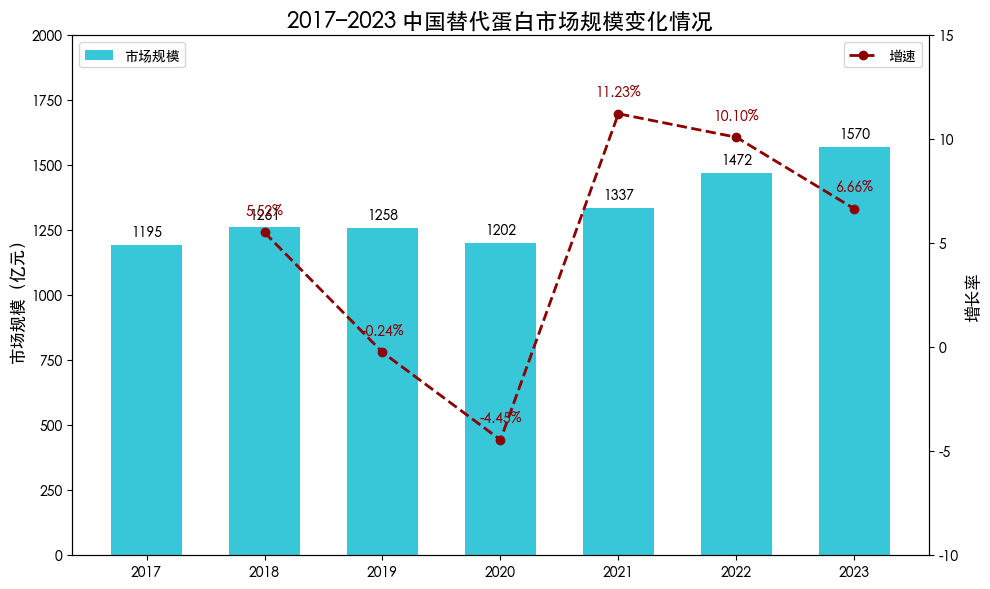

In [14]:
import matplotlib.pyplot as plt
import numpy as np

# 数据
years = np.array([2017, 2018, 2019, 2020, 2021, 2022, 2023])
market_size = [1195, 1261, 1258, 1202, 1337, 1472, 1570]
growth_rate = [None, 5.52, -0.24, -4.45, 11.23, 10.10, 6.66]

# 创建图形
fig, ax1 = plt.subplots(figsize=(10, 6))

# 柱状图
bar = ax1.bar(years, market_size, color='#38C6D9', width=0.6, label='市场规模')
ax1.set_ylabel('市场规模（亿元）', fontsize=12)
ax1.set_ylim(0, 2000)

# 标注值
for i, val in enumerate(market_size):
    ax1.text(years[i], val + 30, str(val), ha='center', fontsize=10)

# 折线图
ax2 = ax1.twinx()
ax2.plot(years[1:], growth_rate[1:], color='darkred', linestyle='--', marker='o', linewidth=2, label='增速')
for i, val in enumerate(growth_rate[1:], 1):
    ax2.text(years[i], growth_rate[i] + 0.8, f'{val:.2f}%', color='darkred', fontsize=10, ha='center')

ax2.set_ylabel('增长率', fontsize=12)
ax2.set_ylim(-10, 15)

# 标题与图例
plt.title('2017–2023 中国替代蛋白市场规模变化情况', fontsize=16, weight='bold')
ax1.legend(loc='upper left')
ax2.legend(loc='upper right')
plt.tight_layout()
plt.show()


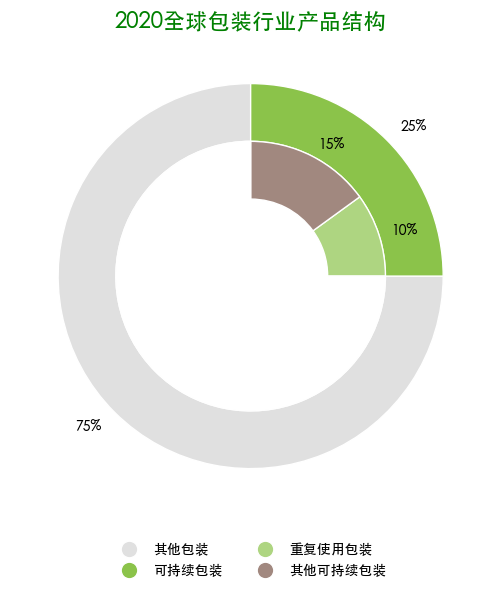

In [15]:
import matplotlib.pyplot as plt

# 设置主类数据
main_labels = ['其他包装', '可持续包装']
main_sizes = [75, 25]
main_colors = ['#E0E0E0', '#8BC34A']

# 设置可持续包装内部细分类数据
inner_labels = ['重复使用包装', '其他可持续包装', '其他包装（不细分）']
inner_sizes = [10, 15, 75]
inner_colors = ['#AED581', '#A1887F', '#FFFFFF00']  # 第三项透明（让“其他包装”不再重复显示）

# 创建图表
fig, ax = plt.subplots(figsize=(8, 6))

# 外圈（主分类）
wedges1, _ = ax.pie(
    main_sizes,
    radius=1,
    labels=[f'{v}%' for v in main_sizes],
    colors=main_colors,
    startangle=90,
    wedgeprops=dict(width=0.3, edgecolor='white')
)

# 内圈（可持续包装细分类）
wedges2, _ = ax.pie(
    inner_sizes,
    radius=1 - 0.3,
    labels=['10%', '15%', ''],
    colors=inner_colors,
    startangle=0,
    wedgeprops=dict(width=0.3, edgecolor='white')
)

# 添加标题
plt.title('2020全球包装行业产品结构', fontsize=16, color='green', weight='bold')

# 图例说明
custom_legend = [
    plt.Line2D([0], [0], marker='o', color='w', label='其他包装', markerfacecolor='#E0E0E0', markersize=12),
    plt.Line2D([0], [0], marker='o', color='w', label='可持续包装', markerfacecolor='#8BC34A', markersize=12),
    plt.Line2D([0], [0], marker='o', color='w', label='重复使用包装', markerfacecolor='#AED581', markersize=12),
    plt.Line2D([0], [0], marker='o', color='w', label='其他可持续包装', markerfacecolor='#A1887F', markersize=12)
]
plt.legend(handles=custom_legend, loc='lower center', bbox_to_anchor=(0.5, -0.15), ncol=2, fontsize=10, frameon=False)

plt.tight_layout()
plt.show()
